In [3]:
import nltk

nltk.download('punkt')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('treebank')

[nltk_data] Downloading package punkt to /home/ariel/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /home/ariel/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package treebank to /home/ariel/nltk_data...
[nltk_data]   Package treebank is already up-to-date!


True

# English case

In [8]:
from nltk import word_tokenize, pos_tag

sentence_en = "Researchers are evaluating different models for natural language processing."

tokens_en = word_tokenize(sentence_en)
tags_en = pos_tag(tokens_en)

print(tags_en)

[('Researchers', 'NNS'), ('are', 'VBP'), ('evaluating', 'VBG'), ('different', 'JJ'), ('models', 'NNS'), ('for', 'IN'), ('natural', 'JJ'), ('language', 'NN'), ('processing', 'NN'), ('.', '.')]


# Spanish case

In [9]:
import spacy

nlp = spacy.load("es_core_news_sm")

sentence_es = "Los investigadores están evaluando diferentes modelos."
doc = nlp(sentence_es)

tags_es = [(token.text, token.pos_) for token in doc]
print(tags_es)

[('Los', 'DET'), ('investigadores', 'NOUN'), ('están', 'AUX'), ('evaluando', 'VERB'), ('diferentes', 'DET'), ('modelos', 'NOUN'), ('.', 'PUNCT')]


# Most frecuent tags

In [10]:
from collections import Counter

# inglés
tag_counts_en = Counter(tag for word, tag in tags_en)
print(tag_counts_en.most_common(1))

# español
tag_counts_es = Counter(tag for word, tag in tags_es)
print(tag_counts_es.most_common(1))

[('NNS', 2)]
[('DET', 2)]


In [11]:
print(tags_en)

[('Researchers', 'NNS'), ('are', 'VBP'), ('evaluating', 'VBG'), ('different', 'JJ'), ('models', 'NNS'), ('for', 'IN'), ('natural', 'JJ'), ('language', 'NN'), ('processing', 'NN'), ('.', '.')]


In [12]:
print(tags_es)

[('Los', 'DET'), ('investigadores', 'NOUN'), ('están', 'AUX'), ('evaluando', 'VERB'), ('diferentes', 'DET'), ('modelos', 'NOUN'), ('.', 'PUNCT')]


# Errors

1. "diferentes" was incorrectly tagged as DET instead of ADJ, since it modifies the noun "modelos".
2. "processing" was tagged as NN, but in context it is part of a verbal or compound expression.
3. The phrase "natural language processing" is not recognized as a single semantic unit, showing a limitation in handling multi-word expressions.

# Training models

In [13]:
from nltk.corpus import treebank
from nltk.tag import UnigramTagger, BigramTagger

tagged_sents = treebank.tagged_sents()

train = tagged_sents[:3000]
test = tagged_sents[3000:3500]

unigram = UnigramTagger(train)
bigram = BigramTagger(train)

# Metrics

In [14]:
print("Unigram:", unigram.evaluate(test))
print("Bigram:", bigram.evaluate(test))

/tmp/ipykernel_127519/3823588242.py:1: DeprecationWarning: 
  Function evaluate() has been deprecated.  Use accuracy(gold)
  instead.
  print("Unigram:", unigram.evaluate(test))
/tmp/ipykernel_127519/3823588242.py:2: DeprecationWarning: 
  Function evaluate() has been deprecated.  Use accuracy(gold)
  instead.
  print("Bigram:", bigram.evaluate(test))


Unigram: 0.8635867871611094
Bigram: 0.10930196322842006


In [15]:
for sent in test[:5]:
    print("REAL:", sent)
    print("PRED:", bigram.tag([w for w, t in sent]))
    print()

REAL: [('At', 'IN'), ('Tokyo', 'NNP'), (',', ','), ('the', 'DT'), ('Nikkei', 'NNP'), ('index', 'NN'), ('of', 'IN'), ('225', 'CD'), ('selected', 'VBN'), ('issues', 'NNS'), (',', ','), ('which', 'WDT'), ('*T*-1', '-NONE-'), ('gained', 'VBD'), ('132', 'CD'), ('points', 'NNS'), ('Tuesday', 'NNP'), (',', ','), ('added', 'VBD'), ('14.99', 'CD'), ('points', 'NNS'), ('to', 'TO'), ('35564.43', 'CD'), ('.', '.')]
PRED: [('At', 'IN'), ('Tokyo', 'NNP'), (',', ','), ('the', 'DT'), ('Nikkei', None), ('index', None), ('of', None), ('225', None), ('selected', None), ('issues', None), (',', None), ('which', None), ('*T*-1', None), ('gained', None), ('132', None), ('points', None), ('Tuesday', None), (',', None), ('added', None), ('14.99', None), ('points', None), ('to', None), ('35564.43', None), ('.', None)]

REAL: [('In', 'IN'), ('early', 'RB'), ('trading', 'NN'), ('in', 'IN'), ('Tokyo', 'NNP'), ('Thursday', 'NNP'), (',', ','), ('the', 'DT'), ('Nikkei', 'NNP'), ('index', 'NN'), ('fell', 'VBD'), ('63.

In [16]:
sample = tagged_sents[:100]

In [17]:
from collections import Counter

all_tags = []

for sent in sample:
    for word, tag in sent:
        all_tags.append(tag)

tag_freq = Counter(all_tags)
top10 = tag_freq.most_common(10)

print(top10)

[('NN', 334), ('IN', 266), ('NNP', 233), ('DT', 223), ('NNS', 188), ('JJ', 135), ('-NONE-', 132), (',', 117), ('.', 101), ('CD', 93)]


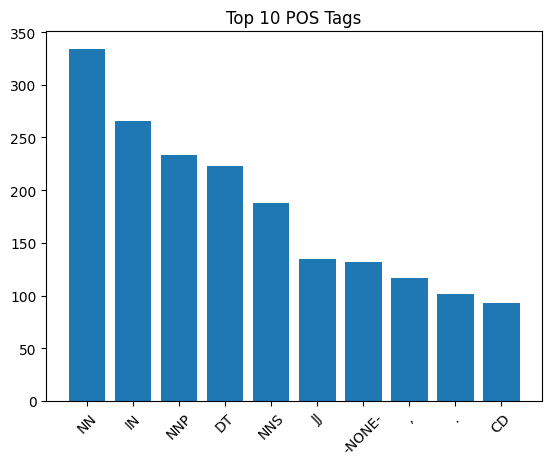

In [18]:
import matplotlib.pyplot as plt

tags, counts = zip(*top10)

plt.bar(tags, counts)
plt.title("Top 10 POS Tags")
plt.xticks(rotation=45)
plt.show()

# Training with generated dataset

In [30]:
import spacy

nlp = spacy.load("es_core_news_sm")

text = """
Los investigadores están evaluando diferentes modelos de procesamiento de lenguaje natural.
El sistema aprende patrones a partir de los datos.
Los modelos estadísticos pueden fallar en contextos complejos.
El análisis de texto es importante en inteligencia artificial.

Muchos algoritmos requieren grandes cantidades de datos para entrenarse correctamente.
La calidad de los datos influye directamente en el rendimiento del modelo.
Los sistemas de aprendizaje automático pueden generalizar si están bien entrenados.
El procesamiento de lenguaje natural permite analizar grandes volúmenes de texto.

Los modelos basados en redes neuronales han mejorado significativamente en los últimos años.
Sin embargo, todavía existen desafíos en la comprensión semántica profunda.
El contexto es fundamental para interpretar correctamente una oración.
Las palabras pueden tener múltiples significados dependiendo de su uso.

El desarrollo de aplicaciones inteligentes depende del avance en estas tecnologías.
Los investigadores comparan diferentes enfoques para encontrar mejores resultados.
El uso de corpus etiquetados facilita el entrenamiento de modelos supervisados.
Las herramientas modernas permiten automatizar muchas tareas de análisis.

En algunos casos, los modelos cometen errores debido a ambigüedades lingüísticas.
Por ejemplo, una palabra puede funcionar como sustantivo o verbo.
Esto representa un reto importante en el etiquetado gramatical.
Los sistemas deben ser capaces de adaptarse a diferentes dominios.

El aprendizaje profundo ha revolucionado el campo de la inteligencia artificial.
Los modelos actuales pueden generar texto, traducir idiomas y responder preguntas.
A pesar de estos avances, es importante evaluar cuidadosamente los resultados.
La interpretación de los modelos sigue siendo un área de investigación activa.

Finalmente, la combinación de técnicas estadísticas y neuronales puede mejorar el desempeño.
Los investigadores continúan explorando nuevas metodologías y arquitecturas.
El futuro del procesamiento de lenguaje natural es prometedor y lleno de oportunidades.
"""

doc = nlp(text)

data = []
sentence = []

for token in doc:
    if token.text == ".":
        sentence.append((token.text, token.pos_))
        data.append(sentence)
        sentence = []
    else:
        sentence.append((token.text, token.pos_))

print(data)

[[('\n', 'SPACE'), ('Los', 'DET'), ('investigadores', 'NOUN'), ('están', 'AUX'), ('evaluando', 'VERB'), ('diferentes', 'DET'), ('modelos', 'NOUN'), ('de', 'ADP'), ('procesamiento', 'NOUN'), ('de', 'ADP'), ('lenguaje', 'NOUN'), ('natural', 'ADJ'), ('.', 'PUNCT')], [('\n', 'SPACE'), ('El', 'DET'), ('sistema', 'NOUN'), ('aprende', 'VERB'), ('patrones', 'NOUN'), ('a', 'ADP'), ('partir', 'NOUN'), ('de', 'ADP'), ('los', 'DET'), ('datos', 'NOUN'), ('.', 'PUNCT')], [('\n', 'SPACE'), ('Los', 'DET'), ('modelos', 'NOUN'), ('estadísticos', 'ADJ'), ('pueden', 'AUX'), ('fallar', 'VERB'), ('en', 'ADP'), ('contextos', 'NOUN'), ('complejos', 'ADJ'), ('.', 'PUNCT')], [('\n', 'SPACE'), ('El', 'DET'), ('análisis', 'NOUN'), ('de', 'ADP'), ('texto', 'NOUN'), ('es', 'AUX'), ('importante', 'ADJ'), ('en', 'ADP'), ('inteligencia', 'NOUN'), ('artificial', 'ADJ'), ('.', 'PUNCT')], [('\n\n', 'SPACE'), ('Muchos', 'DET'), ('algoritmos', 'NOUN'), ('requieren', 'VERB'), ('grandes', 'ADJ'), ('cantidades', 'NOUN'), ('de

In [31]:
total_tokens = sum(len(sent) for sent in data)
print(total_tokens)

341


In [32]:
split = int(len(data) * 0.8)

train = data[:split]
test = data[split:]

In [33]:
from sklearn.metrics import classification_report
from nltk.tag import DefaultTagger

default = DefaultTagger('NN')  # fallback final
unigram = UnigramTagger(train, backoff=default)
bigram = BigramTagger(train, backoff=unigram)

y_true = []
y_pred = []

for sent in test:
    words = [w for w, t in sent]
    true_tags = [t for w, t in sent]
    pred_tags = unigram.tag(words)

    for (_, pred), true in zip(pred_tags, true_tags):
        y_true.append(true)
        y_pred.append(pred)

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

         ADJ       1.00      0.33      0.50         9
         ADP       1.00      0.88      0.93         8
         ADV       0.00      0.00      0.00         2
         AUX       1.00      0.80      0.89         5
       CCONJ       0.00      0.00      0.00         4
         DET       1.00      0.90      0.95        10
          NN       0.00      0.00      0.00         0
        NOUN       1.00      0.33      0.50        21
       PUNCT       1.00      1.00      1.00         9
       SPACE       1.00      1.00      1.00         6
        VERB       0.00      0.00      0.00         8

    accuracy                           0.55        82
   macro avg       0.64      0.48      0.52        82
weighted avg       0.83      0.55      0.63        82



/home/ariel/Escritorio/proyectos/nlp/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/ariel/Escritorio/proyectos/nlp/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/ariel/Escritorio/proyectos/nlp/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modif

# Rule-based heuristics (suffix-based tagging)

In [34]:
def suffix_tagger(word):
    if word.endswith("mente"):
        return "ADV"
    elif word.endswith("ción"):
        return "NOUN"
    elif word.endswith("ando") or word.endswith("iendo"):
        return "VERB"
    elif word[0].isupper():
        return "PROPN"
    else:
        return None

In [35]:
from nltk.tag import UnigramTagger, BigramTagger, DefaultTagger

class RuleTagger:
    def tag(self, tokens):
        return [(w, suffix_tagger(w)) for w in tokens]

default = DefaultTagger("NOUN")
unigram = UnigramTagger(train, backoff=default)
bigram = BigramTagger(train, backoff=unigram)

In [36]:
def word2features(sent, i):
    word = sent[i][0]

    features = {
        'word': word,
        'lower': word.lower(),
        'suffix3': word[-3:],
        'is_upper': word.isupper(),
        'is_title': word.istitle(),
    }

    if i > 0:
        prev = sent[i-1][0]
        features['prev_word'] = prev

    return features

In [37]:
import sklearn_crfsuite

X_train = [[word2features(s, i) for i in range(len(s))] for s in train]
y_train = [[tag for _, tag in s] for s in train]

crf = sklearn_crfsuite.CRF()
crf.fit(X_train, y_train)

,algorithm,None
,min_freq,None
,all_possible_states,None
,all_possible_transitions,None
,c1,None
,c2,None
,max_iterations,None
,num_memories,None
,epsilon,None
,period,None
,delta,None


In [38]:
X_test = [[word2features(s, i) for i in range(len(s))] for s in test]
y_test = [[tag for _, tag in s] for s in test]

y_pred = crf.predict(X_test)

In [39]:
print("Unigram:", unigram.accuracy(test))
print("Bigram:", bigram.accuracy(test))

Unigram: 0.7195121951219512
Bigram: 0.7195121951219512


The UnigramTagger and BigramTagger achieved the same accuracy (0.7195). 

This indicates that the BigramTagger was not able to effectively leverage contextual information. 
Due to the limited size of the dataset, many word-context combinations were not seen during training, 
causing the BigramTagger to rely heavily on the UnigramTagger through the backoff mechanism.